# Dataset exploration

<div style="text-align: justify">

Notebook used to analyse the dataset. Analysis focuses on the metadata and their statistical distributions (airport IDs, runway IDs, aircraft positions, aircraft attitudes, time-of-day, ...). Analysis is performed on the raw data obtained via running the [`data-download.ipynb`](./data-download.ipynb) notebook.
</div>

> Notebook inspired from G. Delhomme's work. [[Github]](https://github.com/geoffrey-g-delhomme/lard-yolov8)

In [1]:
from pathlib import Path

import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
import seaborn as sns

## Notes:
## -----
## Mime type rendering requires nbformat>=4.2.0, to be installed by hand

In [81]:
# Setup paths
LARD_DATASETS_PATH = "../../LARD_dataset"

## Load the (raw) data

In [82]:
# Only load the synthetic data
train_archives = [
    ("LARD_train_BIRK_LFST.zip", "LARD_train_BIRK_LFST.csv"),
    ("LARD_train_DAAG_DIAP.zip", "LARD_train_DAAG_DIAP.csv"),
    ("LARD_train_KMSY.zip", "LARD_train_KMSY.csv"),
    ("LARD_train_LFMP_LFPO.zip", "LARD_train_LFMP_LFPO.csv"),
    ("LARD_train_LFQQ.zip", "LARD_train_LFQQ.csv"),
    ("LARD_train_LPPT_SRLI.zip", "LARD_train_LPPT_SRLI.csv"),
    ("LARD_train_VABB.zip", "LARD_train_VABB.csv"),
    # ("LARD_train_domain_adaptation.zip", "LARD_train_domain_adaptation.csv")
]
tests_archives = [
    ("LARD_test_synth.zip", "LARD_test_synth.csv"),
]

<div style="text-align: justified", class="alert alert-danger">

To load the data that was downloaded with the [`data-download.ipynb`](./data-download.ipynb) notebook, make sure to have the same `LARD_DATASETS_PATH` value to be set to the folder in which the datasets were stored.
</div>

In [83]:
LARD_dpath = Path(LARD_DATASETS_PATH).resolve()
LARD_train_dpath = LARD_dpath / 'LARD_train'
LARD_tests_dpath = LARD_dpath / 'LARD_test'

In [84]:
# Load the train datasets into a pandas DataFrame
dfs_train = []
for zip_fname, csv_fname in train_archives:
    csv_fpath = LARD_train_dpath / zip_fname.rpartition('.')[0] / csv_fname
    dfs_train.append(pd.read_csv(csv_fpath.as_posix(), delimiter=';'))

df_train = pd.concat(dfs_train).reset_index(drop=True)
df_train['split'] = 'train'

# Load the test datasets into a pandas DataFrame
dfs_test = []
for zip_fname, csv_fname in tests_archives:
    csv_fpath = LARD_tests_dpath / zip_fname.rpartition('.')[0] / csv_fname
    dfs_test.append(pd.read_csv(csv_fpath.as_posix(), delimiter=';'))

df_test = pd.concat(dfs_test).reset_index(drop=True)
df_test['split'] = 'test'

# Merge both pd.DataFrames 
df = pd.concat((df_train, df_test)).reset_index(drop=True)
df['watermark_height'] = df['watermark_height'].fillna(0.0)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14424 entries, 0 to 14423
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image                 14424 non-null  object 
 1   height                14424 non-null  int64  
 2   width                 14424 non-null  int64  
 3   type                  14424 non-null  object 
 4   original_dataset      14424 non-null  object 
 5   scenario              14424 non-null  object 
 6   airport               14424 non-null  object 
 7   runway                14424 non-null  object 
 8   time_to_landing       0 non-null      float64
 9   weather               0 non-null      float64
 10  night                 0 non-null      float64
 11  time                  14424 non-null  object 
 12  slant_distance        14424 non-null  float64
 13  along_track_distance  14424 non-null  float64
 14  height_above_runway   14424 non-null  float64
 15  lateral_path_angle 

In [85]:
df['split'].value_counts()

split
train    12212
test      2212
Name: count, dtype: int64

In [86]:
print('Images dimensions:\n')
print(df['height'].value_counts())
print()
print(df['width'].value_counts())

Images dimensions:

height
2648    14424
Name: count, dtype: int64

width
2448    14424
Name: count, dtype: int64


In [87]:
print(f"Airprt unique ids (train, {df[df['split']=='train']['airport'].unique().size})")
df[df['split']=="train"]['airport'].value_counts(sort=True)

Airprt unique ids (train, 11)


airport
VABB    1817
LFQQ    1816
KMSY    1814
LFPO    1335
SRLI     919
BIRK     917
LFST     902
DIAP     893
DAAG     891
LFMP     454
LPPT     454
Name: count, dtype: int64

In [88]:
df['rwy_id'] = df['airport'].astype(str) + '|' + df['runway'].map(lambda x: f"{x:0>3}")

print(f"Runway unique ids (train, {df[df['split']=='train']['rwy_id'].unique().size})")
df[df['split']=="train"]['rwy_id'].value_counts(sort=False)

Runway unique ids (train, 27)


rwy_id
BIRK|001    461
BIRK|013    456
LFST|005    454
LFST|023    448
DAAG|005    452
DAAG|023    439
DIAP|003    446
DIAP|021    447
KMSY|011    447
KMSY|020    454
KMSY|002    467
KMSY|029    446
LFMP|015    454
LFPO|002    435
LFPO|024    452
LFPO|025    448
LFQQ|001    462
LFQQ|008    458
LFQQ|019    447
LFQQ|026    449
LPPT|021    454
SRLI|014    469
SRLI|032    450
VABB|009    455
VABB|014    458
VABB|027    465
VABB|032    439
Name: count, dtype: int64

## DataFrame preproc

Preproc metadata on the aircraft position and attitude within the *generic landing approach cone* (GLAC)

In [89]:
def get_runway_num(rn: str):
    """
    Util function to convert runway number into bearing angle
    """
    if not (isinstance(rn, int) or isinstance(rn, str)):
        raise TypeError("Input 'rn' must be either int or str.")
    
    if isinstance(rn, int):
        return rn
    else:
        s_type = type(rn)
        return int(s_type().join(filter(s_type.isdigit, rn)))

In [90]:
### TEMP HOTFIX TO PROPERLY HANDLE YAW ANGLE ###
import pyproj
from skspatial.objects import Points

PATH_TO_RUNWAY_DATABASE = "../data/runways_database_all.json"


def ecef2llh(x, y, z):
    """
    https://github.com/deel-ai/LARD/blob/LARD_V1/src/ges/geo_utils.py
    """
    R = 6371010
    t = math.sqrt((x**2 + y**2 + z**2))

    if x == 0:
        if y < 0:
            lon = -math.pi / 2
        else:
            lon = math.pi / 2
    elif x < 0:
        if y < 0:
            lon = -math.pi + math.atan(y/x)
        else:
            lon = math.pi + math.atan(y/x)
    else:
        lon = math.atan(y/x)

    lat = math.asin(z/t)
    height = t - R
    return math.degrees(lat), math.degrees(lon), height 


def find_center(points):
    return Points(points).mean_center(return_centroid=True)


def find_azimuth_between_points(lon1, lat1, lon2, lat2):
    """
    https://github.com/deel-ai/LARD/blob/LARD_V1/src/ges/geo_utils.py#L258
    """
    return pyproj.Geod(ellps="WGS84").inv(lon1, lat1, lon2, lat2)


def get_runway_pts(database_file, airport_id, runway_id):
    """
    https://github.com/deel-ai/LARD/blob/LARD_V1/src/ges/ges_dataset.py#L86
    """
    with open(database_file, 'r') as f:
        runway_db = json.load(f)

    # Try adding 0 to the id...
    try:
        runway_pt = runway_db[airport_id][runway_id]
    except:
        runway_pt = runway_db[airport_id][f"{runway_id:0>2}"]

    _, ltp  = find_center([list(runway_pt['C']['position'].values()), list(runway_pt['D']['position'].values())])
    _, fpap = find_center([list(runway_pt['A']['position'].values()), list(runway_pt['B']['position'].values())])

    return runway_pt, ltp, fpap


def get_runway_yaw(database_file, airport_id, runway_id):
    """
    https://github.com/deel-ai/LARD/blob/LARD_V1/src/ges/ges_dataset.py#L107
    """
    print(airport_id, runway_id, end='  \t')
    _, ltp, fpap = get_runway_pts(database_file, airport_id, runway_id)

    fpap_lat, fpap_lon, _ = ecef2llh(*fpap)
    ltp_lat, ltp_lon, _ = ecef2llh(*ltp)
    rwy_psi = find_azimuth_between_points(ltp_lon, ltp_lat, fpap_lon, fpap_lat)
    print(rwy_psi)

    return rwy_psi


def get_dist_between_angles(angle1, angle2):
    """
    Return the distance between two angles modulo 360
    """
    return min((angle1-angle2)%360, (angle2-angle1)%360)


def choose_runway_yaw(rwy_num, rwy_yaw_fwd, rwy_yaw_bwd):
    """
    Select the runway azimuth as close as the runway number as possible
    """
    if get_dist_between_angles(rwy_num*10, rwy_yaw_fwd) < get_dist_between_angles(rwy_num*10, rwy_yaw_bwd):
        return rwy_yaw_fwd
    else:
        return rwy_yaw_bwd

#####################################################

In [91]:
df['ATD'] = df['along_track_distance'] * 1852      # Convert from NM to m
df['LPA'] = np.deg2rad(df['lateral_path_angle'])   # Convert from degrees to radians
df['VPA'] = np.deg2rad(df['vertical_path_angle'])  # Convert from degrees to radians

df['slant_distance'] *= 1.852   # Convert from NM to km

# Derive aircraft position XYZ in runway-centered world coordinates
# - X-axis is along the runway oriented in the landing direction
# - Y-axis is in the horizontal plane, oriented toward right side of the runway
# - Z-axis is orthogonal to the horizontal plane, downward.
df['X'] = -df['ATD']
df['Y'] = +df['ATD'] * np.tan(df['LPA'])
df['Z'] = -df['ATD'] * np.tan(df['VPA'])

df['airport'] = df['airport'].astype(str)
df['runway']  = df['runway'].astype(str)

## Compute the runway azimuth ##
df['rwy_yaw'] = 0.0
for airport_id in df['airport'].unique():
    for runway_id in df[df['airport']==airport_id]['runway'].unique():
        rwy_num = get_runway_num(runway_id)
        rwy_yaw = get_runway_yaw(PATH_TO_RUNWAY_DATABASE, airport_id, runway_id)
        df.loc[(df['airport']==airport_id)&(df['runway']==runway_id), 'rwy_yaw'] = choose_runway_yaw(
            rwy_num, rwy_yaw[0], rwy_yaw[1]
        )
################################

# Derive aircraft attitude wrt usual standard
df['phi'] = np.deg2rad(df['roll'])
df['psi'] = np.deg2rad((df['yaw'] - df['rwy_yaw'] + 180) % 360 - 180)
df['theta'] = np.deg2rad(df['pitch'] - 90)

BIRK 1  	(175.2718380895036, -4.725904257654776, 1482.9439923135924)
BIRK 13  	(-63.70754338074329, 116.27317768393974, 1163.8541115686448)
LFST 5  	(-131.29428825419913, 48.687430756516335, 2397.960660988549)
LFST 23  	(48.68743075651632, -131.29428825419913, 2397.960660988549)
DAAG 5  	(-127.15648710402074, 52.82485791005844, 3499.9130263160337)
DAAG 23  	(52.82485791005844, -127.15648710402074, 3499.9130263160337)
DIAP 3  	(-157.55099961642142, 22.44805263967868, 3000.4640128272536)
DIAP 21  	(22.448052639678686, -157.55099961642142, 3000.4640128272536)
KMSY 11  	(-74.51765169348562, 105.46744070936957, 2985.806773638736)
KMSY 20  	(15.474337298062528, -164.5227125600732, 2134.07645861)
KMSY 2  	(-164.5227125600732, 15.474337298062522, 2134.07645861)
KMSY 29  	(105.46744070936957, -74.51765169348562, 2985.806773638736)
LFMP 15  	(-31.681497720750627, 148.308341573079, 2333.4513331833987)
LFPO 2  	(-161.6555865331465, 18.336703937157438, 2398.2900878514693)
LFPO 24  	(61.858955370441

Preproc data labels (bounding boxes)

In [92]:
def _util_compute_bbox_h(bbox_ys: np.ndarray): 
    return bbox_ys.max() - bbox_ys.min()

def _util_compute_bbox_w(bbox_xs: np.ndarray):
    return bbox_xs.max() - bbox_xs.min()

def _util_compute_bbox_cy(bbox_ys: np.ndarray):
    return (bbox_ys.min() + bbox_ys.max()) / 2.

def _util_compute_bbox_cx(bbox_xs: np.ndarray):
    return (bbox_xs.min() + bbox_xs.max()) / 2.

def _util_compute_mask_area(bbox_xs: np.ndarray, bbox_ys: np.ndarray):
    """Using Shoelace Formula (Gauss's area formula)"""
    return 0.5 * abs(
        bbox_xs[0]*bbox_ys[1] + bbox_xs[1]*bbox_ys[2] + bbox_xs[2]*bbox_ys[3] + bbox_xs[3]*bbox_ys[0] -
        bbox_ys[0]*bbox_xs[1] - bbox_ys[1]*bbox_xs[2] - bbox_ys[2]*bbox_xs[3] - bbox_ys[3]*bbox_xs[0]
    )

In [93]:
df['H'] = df['height'] - 2*df['watermark_height']
df['W'] = df['width']

# Derive bbox properties
df['temp_bbox_xs'] = df[[f"x_{k}" for k in "ABCD"]].apply(lambda r: np.array(r, dtype=np.float32), axis=1)
df['temp_bbox_ys'] = df[[f"y_{k}" for k in "ABCD"]].apply(lambda r: np.array(r, dtype=np.float32), axis=1) - df['watermark_height']

# Bbox h, w, cx, cy
df['bbox_h'] = df['temp_bbox_ys'].map(_util_compute_bbox_h) / df['H']
df['bbox_w'] = df['temp_bbox_xs'].map(_util_compute_bbox_w) / df['W']
df['bbox_cy'] = df['temp_bbox_ys'].map(_util_compute_bbox_cy) / df['H']
df['bbox_cx'] = df['temp_bbox_xs'].map(_util_compute_bbox_cx) / df['W']

# Bbox area & aspect ratio
df['bbox_dev2'] = (df['bbox_cx']-0.5)**2 + (df['bbox_cy']-0.5)**2  # Deviation to image center squared
df['bbox_dev1'] = df['bbox_dev2']**0.5                             # Deviation to image center
df['bbox_area'] = df['bbox_h'] * df['bbox_w']  # bbox normalized area
df['bbox_ar'] = df['bbox_h'] / df['bbox_w']    # bbox aspect ratio
df['bbox_fr'] = df[['temp_bbox_xs', 'temp_bbox_ys']].apply(lambda r: _util_compute_mask_area(*r), axis=1) / df['H'] / df['W'] / df['bbox_area'] 

# Remove temporary columns
df = df.drop(columns=['temp_bbox_xs', 'temp_bbox_ys'])

In [94]:
print(df.columns)

Index(['image', 'height', 'width', 'type', 'original_dataset', 'scenario',
       'airport', 'runway', 'time_to_landing', 'weather', 'night', 'time',
       'slant_distance', 'along_track_distance', 'height_above_runway',
       'lateral_path_angle', 'vertical_path_angle', 'yaw', 'pitch', 'roll',
       'watermark_height', 'x_A', 'y_A', 'x_B', 'y_B', 'x_C', 'y_C', 'x_D',
       'y_D', 'split', 'rwy_id', 'ATD', 'LPA', 'VPA', 'X', 'Y', 'Z', 'rwy_yaw',
       'phi', 'psi', 'theta', 'H', 'W', 'bbox_h', 'bbox_w', 'bbox_cy',
       'bbox_cx', 'bbox_dev2', 'bbox_dev1', 'bbox_area', 'bbox_ar', 'bbox_fr'],
      dtype='object')


## Analysis of metadata

### Analyze the airport / runway distribution

In [95]:
# Extract data of interest
doi = df[['image', 'runway', 'airport', 'split']].groupby(['split', 'airport', 'runway']).count().rename(columns={'image': 'count'}).reset_index()

# Displot pyplot plot
fig = px.sunburst(
    doi,
    path=['split', 'airport', 'runway'],
    values='count',
    color='split',
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
)
fig.show()

In [96]:
fig = px.bar(
    doi,
    x='airport',
    y='count',
    color='split',
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
)
fig.show()

<div style="text-align: justify", class="alert alert-info">

**Remark**

For train data, there are about 500 images per runway record, for 1 to 4 runways per airport and for a total of 12 airports. For test data, a disjoint set of airports is used, with a variable number of runway records for each (1 to 4) and a small number of images per record (about 30).
</div>

### Analyze the time-of-day distribution

<div style='text-align: justify'>

Note that there are 3 metadata properties that are not available for the synthetic data: `time_to_landing`, `weather`, `night`. These metadata are reserved for real data for which more refined info is not possible.

To check potential coherence of the data with the ODD and especially regarding the day/night aspect, we will have to base the computations on the time-of-day... 

*(Actually, no check on time-of-day will be performed for monitoring...)*
</div>

In [97]:
def _util_convert_time(s):
    """
    Util function to convert datetime from str to float
    """
    tt = s.split()[1]
    hh,mm,ss = tt.split(':')
    return int(hh) + int(mm)/60.0 + int(ss)/3600.0

In [98]:
# Extract data of interest
doi = df[['image', 'airport', 'split', 'time']].groupby(['split', 'time']).count().rename(columns={'image': 'count'}).reset_index()
doi['hours'] = doi['time'].map(_util_convert_time)

# Display graph
fig = px.histogram(
    doi,
    x='hours',
    y='count',
    color='split',
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.update_traces(xbins_size=1)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
)
fig.show()

<div style="text-align: justify", class="alert alert-info">

**Remark**

The distributions of the time-of-day look different between the test and the train datasets. We note the presence of extreme time-of-day values (below 04:30 and above 22:30) which are likely to correspond to data samples taken at night, i.e., outside the specified ODD...
</div>

### Analyze the distribution of aircraft positions

In [99]:
fig = px.scatter_3d(
    df,
    x="X",
    y="Y",
    z="Z",
    opacity=0.5,
    color="split",
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.update_traces(marker_size=1)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
    scene=dict(aspectmode='data')
)
fig.show()

<div sryle="text-align: justify", class="alert alert-info">

**Remark**

- The sampled data lies in a cone centered on the standard -3° path nearly the Gaussian sampling diameter augmenting proportionate to the distance from the landing point.
- There is no data test point between ~5000 and ~7500 meters.
</div>

In [100]:
# Display graph
fig = ff.create_distplot(
    [df[df['split']==d]['ATD'].replace([np.inf, -np.inf], np.nan).dropna() for d in ('train', 'test')], ['train', 'test'], bin_size=50
)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
)
fig.show()

In [101]:
# Display graph
fig = px.density_contour(
    df, 
    x='lateral_path_angle',
    y='vertical_path_angle',
    color='split',
    marginal_x='violin',
    marginal_y='violin',
    # range_x=[-1.,+1.],
    # range_y=[-1.,+1.],
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.show()

<div style="text-align: justify", class="alert alert-info">

**Remarks**

- The distribution of the *ATD* is quite different between train and test datasets, probably due to a greater range of values for the training data points.
- The distributions for the *LPA* and *VPA* are more similar between the train and test data points. Still, greater ranges of values are observed for the training data.

As expected, the *VPA* is centered around a -3° slope, the standard in landing approaches.
</div>

In [102]:
# Display graph
fig = ff.create_distplot(
    [df[df['split']==d]['theta'].replace([np.inf, -np.inf], np.nan).dropna() for d in ('train', 'test')], ['train', 'test'], show_hist=False
)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    template="plotly_dark",
    autosize=True,
)
fig.show()

# Display graph
fig = px.density_contour(
    df, 
    x='phi',
    y='psi',
    color='split',
    marginal_x='violin',
    marginal_y='violin',
    # range_x=[-1.,+1.],
    # range_y=[-1.,+1.],
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.show()

<div style="text-align: justify", class="alert alert-info">

**Remarks**

Attitude distributions for train and test datasets are very similar.
</div>

## Analysis of data labels (bounding boxes)

### Analyze the distribution of bbox position and size

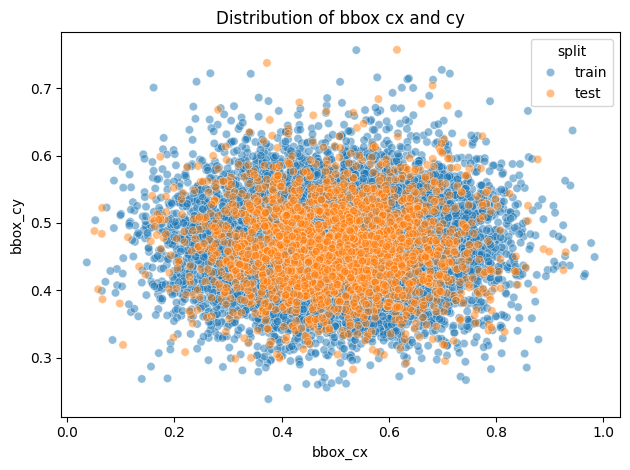

In [95]:
sns.scatterplot(data=df, x='bbox_cx', y='bbox_cy', hue="split", alpha=.5)
plt.title(f"Distribution of bbox cx and cy")
plt.tight_layout()
plt.show()

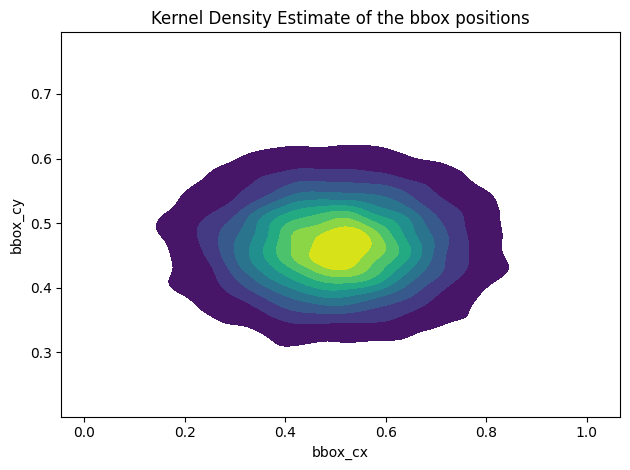

In [96]:
sns.kdeplot(data=df[['bbox_cx','bbox_cy']], x="bbox_cx", y="bbox_cy", cmap="viridis", fill=True, thresh=0.05)
plt.title("Kernel Density Estimate of the bbox positions")
plt.tight_layout()
plt.show()

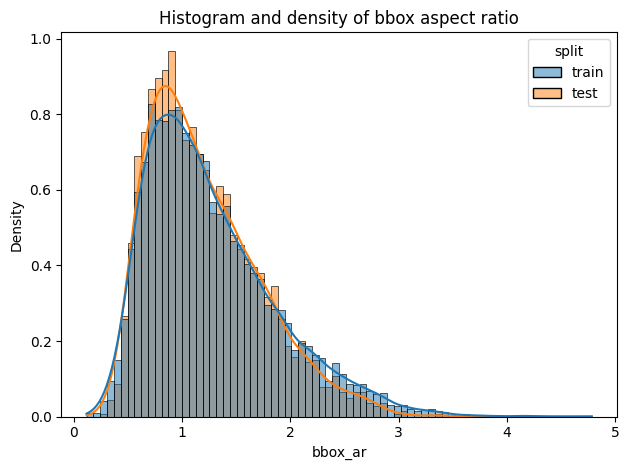

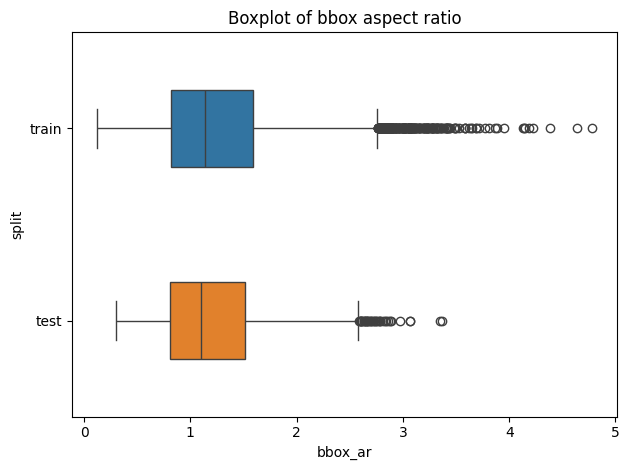

In [97]:
# Histogram
sns.histplot(data=df, x='bbox_ar', kde=True, hue="split", stat="density", common_norm=False)
plt.title("Histogram and density of bbox aspect ratio")
plt.tight_layout()
plt.show()

# Boxplot
sns.boxplot(data=df, x='bbox_ar', y='split', hue="split", gap=0.5, width=0.8)
plt.title("Boxplot of bbox aspect ratio")
plt.tight_layout()
plt.show()

### Analyze the distribution of bbox filling ratio

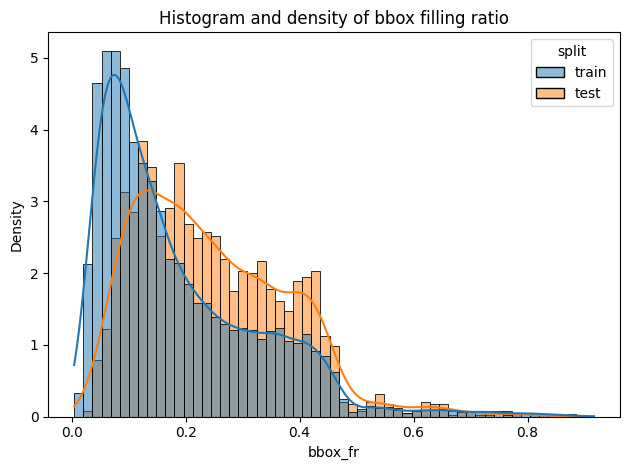

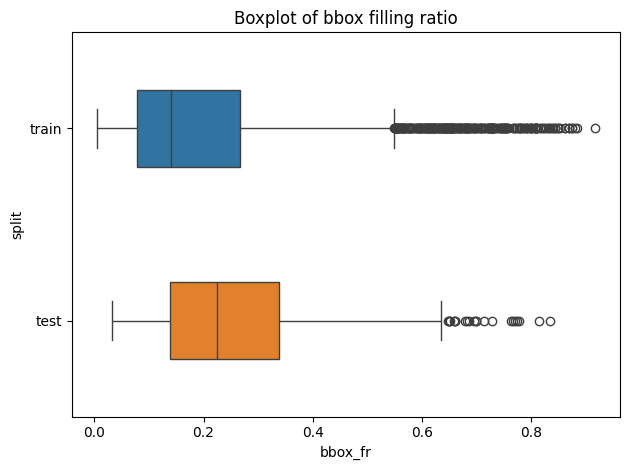

In [98]:
# Histogram
sns.histplot(data=df, x='bbox_fr', kde=True, hue="split", stat="density", common_norm=False)
plt.title("Histogram and density of bbox filling ratio")
plt.tight_layout()
plt.show()

# Boxplot
sns.boxplot(data=df, x='bbox_fr', y='split', hue="split", gap=0.5, width=0.8)
plt.title("Boxplot of bbox filling ratio")
plt.tight_layout()
plt.show()

### Analyze the distribution of bbox area wrt other variables

In [99]:
corr_all = df[['bbox_area', 'slant_distance', 'ATD', 'LPA', 'VPA', 'phi', 'theta', 'psi']].corr(numeric_only=True)
corr_tr = df[df['split']=="train"][['bbox_area', 'slant_distance', 'ATD', 'LPA', 'VPA', 'phi', 'theta', 'psi']].corr(numeric_only=True)
corr_te = df[df['split']=="test" ][['bbox_area', 'slant_distance', 'ATD', 'LPA', 'VPA', 'phi', 'theta', 'psi']].corr(numeric_only=True)

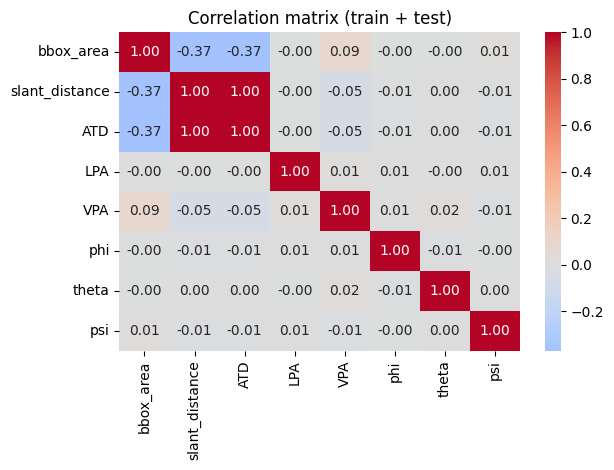

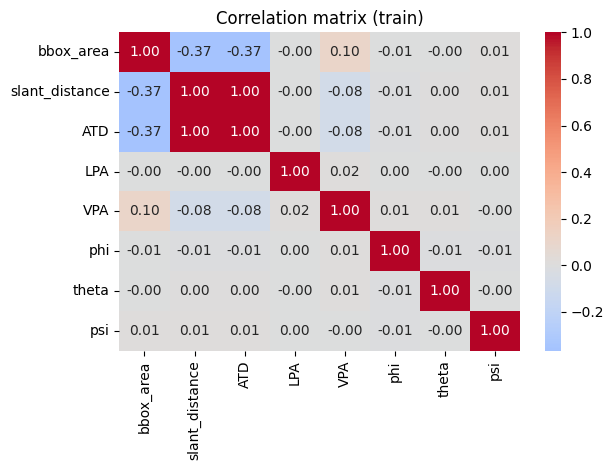

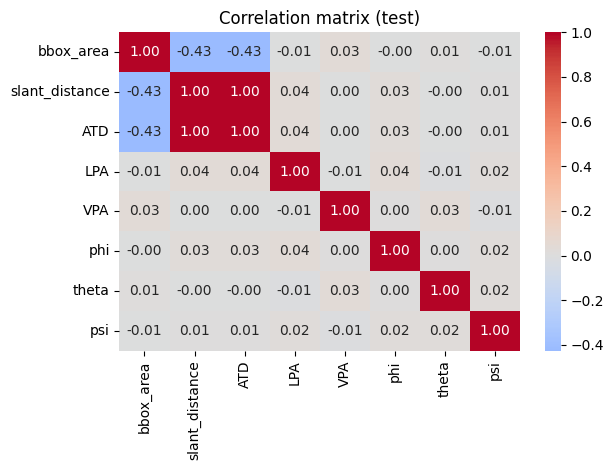

In [100]:
# Corr matrix (train + test)
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation matrix (train + test)")
plt.tight_layout()
plt.show()

# Corr matrix (train)
sns.heatmap(corr_tr, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation matrix (train)")
plt.tight_layout()
plt.show()

# Corr matrix (test)
sns.heatmap(corr_te, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation matrix (test)")
plt.tight_layout()
plt.show()

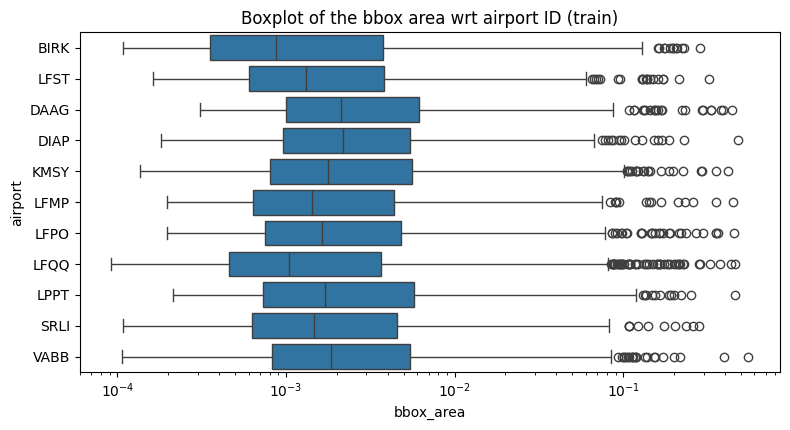

In [101]:
# Focus on train data
N_categories = df[df['split']=='train']['airport'].nunique()
H_categories = 0.4

plt.figure(figsize=(8, N_categories*H_categories))
sns.boxplot(data=df[df['split']=="train"], x='bbox_area', y='airport', log_scale=True)
plt.title("Boxplot of the bbox area wrt airport ID (train)")
plt.tight_layout()
plt.show()

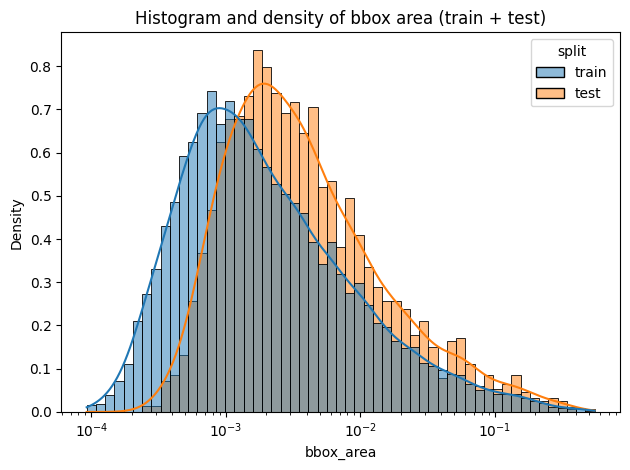

In [102]:
sns.histplot(data=df, x='bbox_area', log_scale=True, hue='split', kde=True, stat='density', common_norm=False)
plt.title("Histogram and density of bbox area (train + test)")
plt.tight_layout()
plt.show()

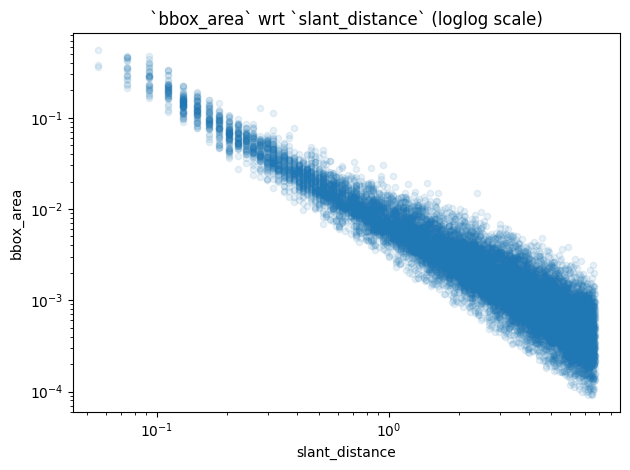

In [103]:
df.plot(x='slant_distance', y='bbox_area', kind='scatter', logy=True, logx=True, alpha=0.1)
plt.title("`bbox_area` wrt `slant_distance` (loglog scale)")
plt.tight_layout()
plt.show()

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

In [105]:
scaler = StandardScaler()

# Extract features and target
y = df['bbox_area'].to_numpy()
X = df[['ATD', 'VPA', 'LPA', 'phi', 'theta', 'psi']].to_numpy()

# Convert to log scale
y_log = np.log(y)
X_log = np.concatenate((np.log(X[:,:1]), X[:,1:]), axis=1) 

# Apply scaler
X_scaled = scaler.fit_transform(X_log)

In [106]:
model = LinearRegression()
model.fit(X_scaled, y_log)

coefs_model = pd.DataFrame({
    'Feats': ['ATD', 'VPA', 'LPA', 'phi', 'theta', 'psi', '_'],
    'Coefs': np.append(model.coef_, model.intercept_)
}) #.sort_values(by='Coefs', key=abs, ascending=False)

In [107]:
print("Coefficients of the LR [bbox_area = f(*pos, *att)]:")
print(coefs_model)

Coefficients of the LR [bbox_area = f(*pos, *att)]:
   Feats     Coefs
0    ATD -1.387827
1    VPA  0.092260
2    LPA  0.006024
3    phi  0.000367
4  theta -0.000678
5    psi  0.018848
6      _ -6.105944


In [108]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y_log)

coefs_lasso = pd.DataFrame({
    'Feats': ['ATD', 'VPA', 'LPA', 'phi', 'theta', 'psi', '_'],
    'Coefs': np.append(lasso.coef_, lasso.intercept_)
}) #.sort_values(by='Coefs', key=abs, ascending=False)

In [109]:
print("Coefficients of the LASSO reg [bbox_area = f(*pos, *att)]:")
print(coefs_lasso)

Coefficients of the LASSO reg [bbox_area = f(*pos, *att)]:
   Feats     Coefs
0    ATD -1.294423
1    VPA  0.000000
2    LPA  0.000000
3    phi  0.000000
4  theta  0.000000
5    psi  0.000000
6      _ -6.105944


<div style="text-align: justify", class="alert alert-info">

**Remarks**

Using the *LASSO* linear regression, we notice that only the coefficient on the **ATD** is influent.
</div>

In [110]:
from sklearn.metrics import mean_squared_error

# Verify the relation
_a = lasso.coef_
_b = lasso.intercept_

_X = scaler.transform(
    np.log(
        np.pad(np.array(df['ATD'].values).reshape(-1, 1), ((0,0), (0,5)), mode='constant', constant_values=1)
    )
)

_y_pred = _X @ _a + _b  # or use lasso.predict(_X)
_y_true = np.log(df['bbox_area'].values)

print("MSE on training data:", mean_squared_error(_y_true, _y_pred))

MSE on training data: 0.2442496990772296


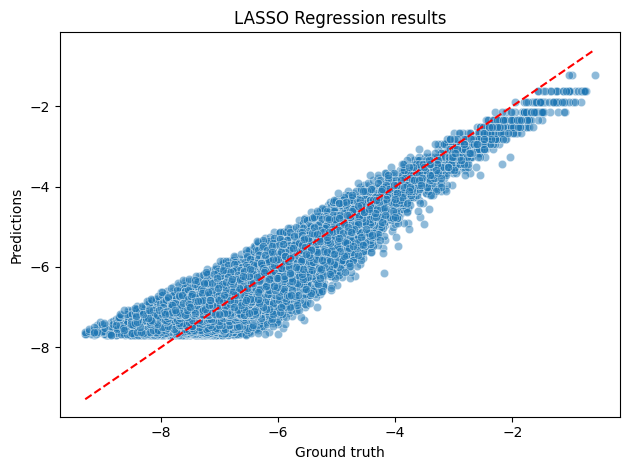

In [111]:
sns.scatterplot(x=_y_true, y=_y_pred, alpha=0.5)
plt.plot([_y_true.min(), _y_true.max()], [_y_true.min(), _y_true.max()], '--r')
plt.xlabel("Ground truth")
plt.ylabel("Predictions")
plt.title("LASSO Regression results")
plt.tight_layout()
plt.show()

<div style="text-align: justify", class="alert alert-success">

**Conclusion**

The bounding box area mostly depends on the **ATD** (*along-track distance*) parameter and follows a linear relation to it:
$$
\hat{y} = -1.29 \cdot X -6.11
$$

with 

- The predicted bbox area being $\hat{y}$;
- The *position* and *attitude* features $X$ (*ATD*, *VPA*, *LPA*, *roll*, *pitch*, *yaw*)
</div>